# Logistic Regression

### 목표
1. predict_proba()코 클래스별 확률 출력 보기
2. decision boundary, 즉 결정 경계 개념을 코드로 확인하기

---

# 1. Logistic Regression 핵심

Logistic Regression 은 입력 데이터 X를 보고 각 클래스에 속할 확률을 계산한 뒤, 가장 확률이 높은 클래스로 분류한다

EX: breast cancer 데이터셋

- 0 = malignant, 악성
- 1 = benign, 양성

모델이 어떤 샘플에 대해 이렇게 예측할 수 있다.

- malignant 확률 = 0.12
- benign 확률    = 0.88

그러면 최종 예측은 benign이 된다.

즉:
- predict_proba() -> 클래스별 확률
- predict()       -> 최종 예측 클래스

---

# 2. Breast Cancer 데이터셋으로 확률 출력 

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import pandas as pd

# 1. 데이터 가져오기
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

# 2. train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=42,
    test_size=0.2,
    stratify=y
)

# 3. 표준화 + LogisticRegression Pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
    # max_iter -> 모델이 최적의 가중치 w, b 를 찾기 위해 반복 계산을 최대 몇 번까지 할 것인지 결정
])

# 4. 학습
model.fit(X_train, y_train)

# 5. 예측
pred = model.predict(X_test)

# 6. 확률 출력
proba = model.predict_proba(X_test)

# 7. 정확도
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train 정확도:", train_score)
print("Test 정확도:", test_score)
print("클래스 순서:", model.named_steps["logreg"].classes_)
print("클래스 이름:", cancer.target_names)

Train 정확도: 0.989010989010989
Test 정확도: 0.9824561403508771
클래스 순서: [0 1]
클래스 이름: ['malignant' 'benign']


---

# 3. 예측값과 확률을 표로 확인

In [6]:
result = pd.DataFrame({
    "실제값": y_test,
    "예측값":pred,
    "실제 클래스": cancer.target_names[y_test],
    "예측 클래스": cancer.target_names[pred],
    "악성 확률": proba[:, 0],
    "양성 확률": proba[:, 1]
})

result.head(10)

,실제값,예측값,실제 클래스,예측 클래스,악성 확률,양성 확률
0,0,0,malignant,malignant,1.000000,5.888242e-08
1,1,1,benign,benign,0.000011,9.999887e-01
2,0,0,malignant,malignant,0.993589,6.410825e-03
3,1,1,benign,benign,0.466491,5.335085e-01
4,0,0,malignant,malignant,1.000000,6.525001e-10
5,1,1,benign,benign,0.007840,9.921604e-01
6,1,1,benign,benign,0.000017,9.999828e-01
7,0,0,malignant,malignant,0.999999,5.635275e-07
8,0,0,malignant,malignant,0.999946,5.431637e-05
9,0,0,malignant,malignant,1.000000,8.041849e-11


proba[:, 0] -> 클래스 0일 확률 -> malignant(악성) 확률

proba[:, 1] -> 클래스 1일 확률 -> benign(양성) 확률

즉, 어떤 행이 이렇게 나오면:

- 악성 확률: 0.93
- 양성 확률: 0.97
- 예측 클래스: benign(양성)

모델이 "이 샘플은 양성일 가능성이 높다" 고 본 것임

---

# 4. predict와 predict_proba 차이

In [7]:
print("예측 클래스 앞 5개:")
print(pred[:5])
print()

print("예측 확률 앞 5개:")
print(proba[:5])

예측 클래스 앞 5개:
[0 1 0 1 0]

예측 확률 앞 5개:
[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


### 해석방법

#### predict()
=> 최종 선택한 클래스만 보여줌

#### predict_proba()
=> 각 클래스에 속할 확률을 보여줌

---

# 5. 결정 경계 Decision Boundary 개념

결정 경계는 모델이 클래스를 나누는 기준선이다.

EX: 이진 분류에서

- 양성 확률 >= 0.5 -> 양성
- 양성 확률 < 0.5  -> 악성

이 기준이 바뀌는 지점이 결정 경계다.

즉:
- 클래스 0으로 예측되는 영역
- 클래스 1로 예측되는 영역

이 둘을 나누는 선이 **decision boundary** 다

---

# 6. 결정 경계 시각화 실습

결정 경계는 2차원 그래프에서 보는 게 가장 쉽다.

iris 데이터셋에서 feature 2개만 사용해서 시각화하면

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

# 1. iris 데이터 불러오기
iris = load_iris()

# 2. 시각화를 위해 feature 2개만 사용
# petal length, petal width
X = iris.data[:, [2, 3]]
y = iris.target

# 3. train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. 표준화 + LogisticRegression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

# 5. 훈련
model.fit(X_train, y_train)

print("Train 정확도:", model.score(X_train, y_train))
print("Test 정확도:", model.score(X_test, y_test))

Train 정확도: 0.9666666666666667
Test 정확도: 0.9333333333333333


---

# 7. 결정 경계 그리기

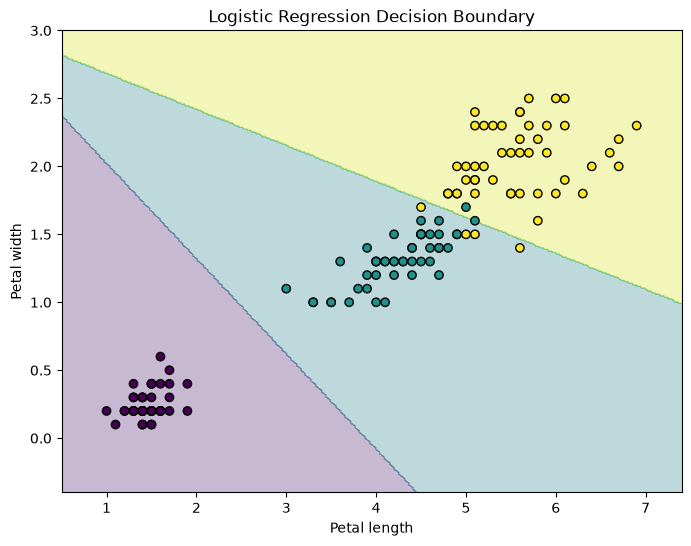

In [ ]:
# 그래프 범위 설정
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# 격자 생성
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300), # x축 범위 300개 점으로 나눔
    np.linspace(y_min, y_max, 300)  # y축 범위 300개 점으로 나눔
)   # 점들은 300x300 = 90,000개

# 격자점들을 모델에 넣어서 예측
# ravel() -> 2차원 배열을 1차원으로
grid_points = np.c_[xx.ravel(), yy.ravel()]  # 두 2차원 배열을 열 방향으로 붙이기
Z = model.predict(grid_points)  # 그래프 전체의 90,000개 점 모델에 넣어 예측
Z = Z.reshape(xx.shape) # 예측 결과를 다시 격자 모양으로 변환

# 결정 경계 시각화
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3)
# contourf -> 영역을 색으로 채움
# alpha=0.3 -> 투명도 -> 값이 낮을수록 배경색 연해짐

plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Logistic Regression Decision Boundary")
plt.show()

---

# 8. 그래프 해석

그래프에서 배경색이 나뉘는 부분이 결정 경계
- 배경색 영역 1 -> 클래스 0으로 예측하는 영역
- 배경색 영역 2 -> 클래스 1로 예측하는 영역
- 배경색 영역 3 -> 클래스 2로 예측하는 영역

점들은 실제 데이터이다
- 점이 자기 클래스 영역 안에 있으면 -> 맞게 분류될 가능성 높음
- 점이 다른 클래스 영역에 있으면 -> 틀릴 가능성 높음
- 점이 경계 근처에 있으면 -> 모델이 헷갈려하는 데이터

---

- Logistic Regression은 분류 모델이다.

- predict()는 최종 클래스를 출력한다.

- predict_proba()는 클래스별 확률을 출력한다.

- 이진 분류에서는 보통 확률 0.5를 기준으로 클래스를 나눈다.

- Decision Boundary는 모델이 클래스를 나누는 경계다.

- Logistic Regression은 기본적으로 선형 결정 경계를 만든다.

- 표준화가 필요한 경우가 많으므로 Pipeline으로 StandardScaler와 같이 쓰는 것이 좋다.